In [2]:
import numpy as np
from sim_library.simulation import simulate_alg_cooling
from sim_library.sequences import RR3_gate, RR3_adjMDFE_500kHz, exchange10_gate, PulseSequence, DownPulse, gen_MDFEup_seq, FreeEvolution
from sim_library.data_io import load_p_dists
from sim_library.plotting import plot_coolingcycles_23, plot_coolingcycles_22, plot_coolingcycles_21, fit_gaussian
from sim_library.constants import k_eff, dR, m, omega_eg, kb
from scipy.constants import hbar, pi
import matplotlib.pyplot as plt
from pathlib import Path

In [8]:
atom_nums = [5000, 10000, 20000, 30000, 50000]

iterations = 20

Temp = 15e-6

cycles = [8,12,16]

rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq

time_steps = 1

RR3_opt = RR3_adjMDFE_500kHz(time_steps=time_steps)
RR3_opt.build_seq()

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

p_shift = 0
initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[p_shift-p_min] = 1
initial_state = initial_state/ np.linalg.norm(initial_state)

bin_width=0.08

rundata = np.full((len(atom_nums), len(cycles), 2, iterations), np.nan)

for n, n_atoms in enumerate(atom_nums):
    for i in range(iterations):
        beam_profile = np.random.normal(loc=1.0, scale=0.0167, size=n_atoms)
        moms_list, fracs_list, _ = simulate_alg_cooling(basis=basis, sequence=RR3_opt, n_atoms=n_atoms, temp=Temp, initial_state=initial_state, beam_profile=beam_profile, cycles=cycles[-1], rabi_freq=rabi_freq, pumping_route='f3',)

        moms_list[:] = [mom / (hbar * k_eff) for mom in moms_list]

        global_min = min([min(m) for m in moms_list])
        global_max = max([max(m) for m in moms_list])
        global_range = (global_min, global_max)

        for c, cyc in enumerate(cycles):
            try:
                amp, T, _, _, _, _ = fit_gaussian(moms_list[cyc*2], fracs=fracs_list[cyc*2], range = global_range, bin_width=bin_width,         
                                                    plot=False,
                                                    plot_residuals=False, 
                                                    print_vals=False,
                                                    threshold=0.33,
                                                    )
            except (RuntimeError, ValueError, TypeError):
                amp = np.nan
                T = np.nan
            rundata[n, c, 0, i] = amp
            rundata[n, c, 1, i] = T
    np.save("rundata.npy", rundata)
    print(f"Saved progress for N = {n_atoms}.")    

print("Script complete.")        


Saved progress for N = 5000.
Saved progress for N = 10000.
Saved progress for N = 20000.
Saved progress for N = 30000.
Saved progress for N = 50000.
Script complete.


In [31]:
rundata_bool = (rundata == np.nan)
print(np.count_nonzero(rundata_bool))

0


In [26]:
rundata_mean = np.nanmean(rundata, axis=3)
rundata_std = np.nanstd(rundata, axis=3)

In [10]:
print(np.shape(rundata_mean))

(5, 3, 2)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


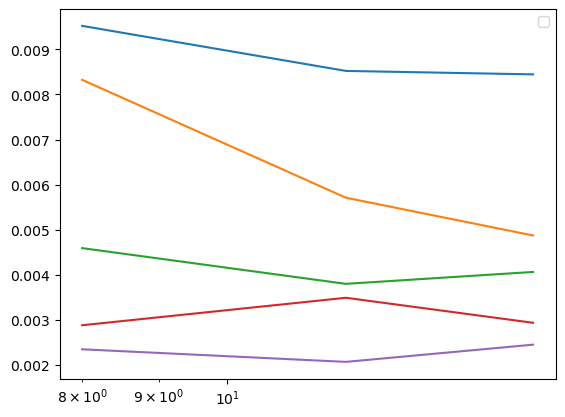

In [27]:
for i in range(len(atom_nums)):
    plt.semilogx(cycles, rundata_std[i,:,0])

plt.legend()


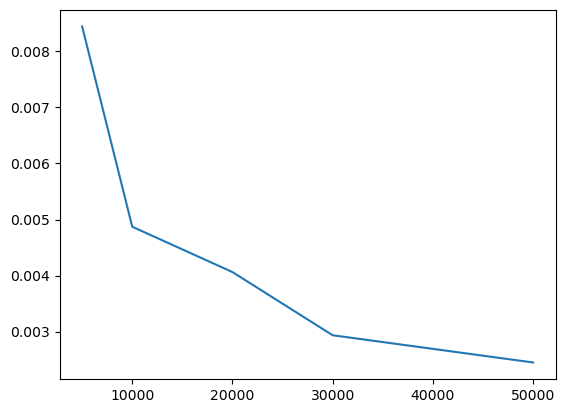

In [71]:
plt.plot(atom_nums, rundata_std[:,2,0])

[80.71788512 -0.11600529]
[ 6.42510837e+01 -6.09773787e-02]
[ 6.04532928e+01 -4.59352680e-02]


Text(0.5, 0.98, 'Error Scaling of Cooling Efficiency')

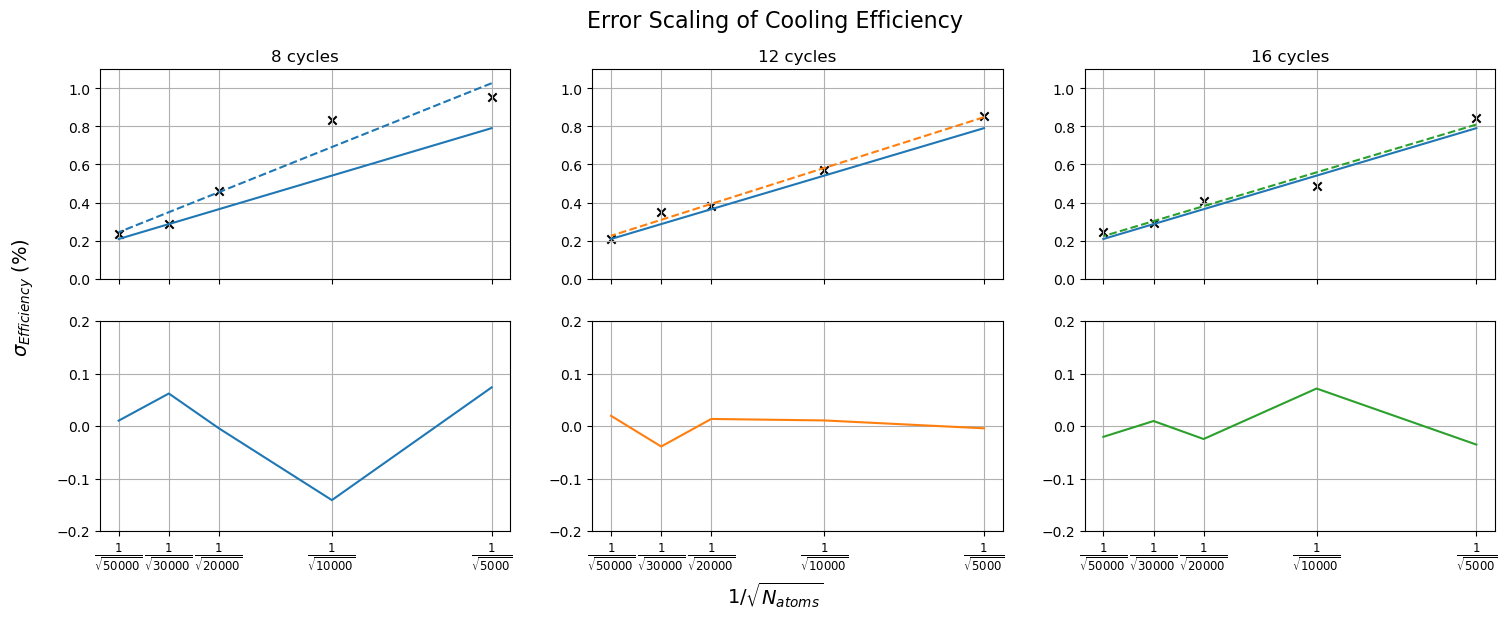

In [111]:
oneoverrootn = 1/np.sqrt(atom_nums)
sigma_eff = rundata_std[:,:,0]*100


fig, axes = plt.subplots(2,3, figsize=(18,6))

param_idx = 0

colours = ['tab:blue', 'tab:orange', 'tab:green']

for i in range(3):
    axes[0,i].scatter(oneoverrootn, sigma_eff[:,i], c= 'black', marker='x')
    coeff = np.polyfit(oneoverrootn, sigma_eff[:,i], deg=1)
    print(coeff)
    yfit = coeff[0]*oneoverrootn + coeff[1]
    axes[0,i].plot(oneoverrootn,yfit, c=colours[i], ls='--')
    residuals = yfit - sigma_eff[:,i]
    axes[1,i].plot(oneoverrootn,residuals, c=colours[i])
    axes[0,i].plot(oneoverrootn, oneoverrootn*60.045 + -0.059)
    axes[0,i].set_xticks(oneoverrootn,[])
    axes[1,i].set_xticks(oneoverrootn,[r'$\frac{1}{\sqrt{5000}}$',r'$\frac{1}{\sqrt{10000}}$',r'$\frac{1}{\sqrt{20000}}$',r'$\frac{1}{\sqrt{30000}}$',r'$\frac{1}{\sqrt{50000}}$'], fontsize=12)
    axes[0,i].grid()
    axes[1,i].grid()
    axes[0,i].set_ylim(0,1.1)
    axes[1,i].set_ylim(-0.2,0.2)
    axes[0,i].set_title(f'{cycles[i]} cycles')
    

fig.supylabel(r'$\sigma_{Efficiency}$ (%)', fontsize=14, x=0.075)
fig.supxlabel(r'$1/\sqrt{N_{atoms}}$', fontsize=14, y=-0.02)
fig.suptitle('Error Scaling of Cooling Efficiency', fontsize=16)

# fig.supylabel(r'$\sigma_{Efficiency}$ (%)', fontsize=14, x=0.068)
# fig.supxlabel(r'$1/\sqrt{N_{atoms}}$', fontsize=14, y=-0.01)
# fig.suptitle('Error Scaling of Cooling Efficiency', fontsize=16)




[1019.38170364   -1.56011802]
[708.72131948  -1.11528476]
[687.61417023  -1.30323905]


Text(0.5, 0.98, 'Error Scaling of Temperature')

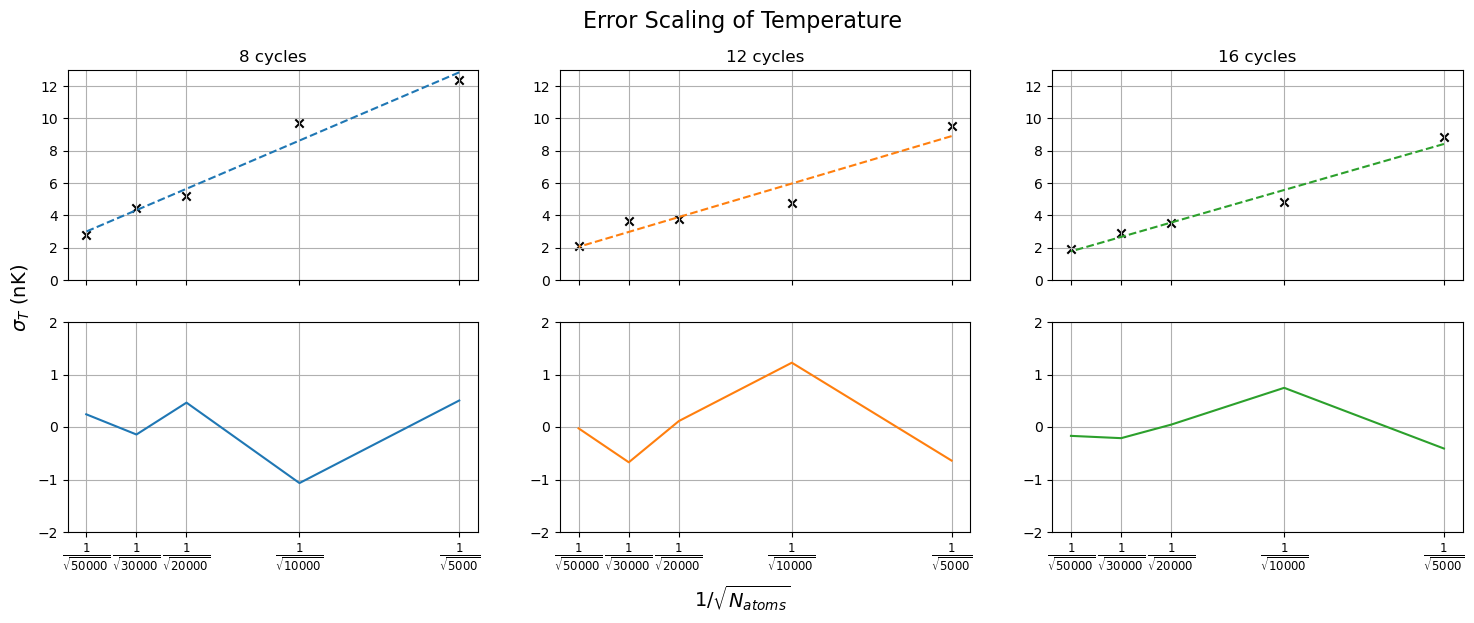

In [104]:
oneoverrootn = 1/np.sqrt(atom_nums)
sigma_T = rundata_std[:,:,1]*1e9

fig, axes = plt.subplots(2,3, figsize=(18,6))

param_idx = 1

colours = ['tab:blue', 'tab:orange', 'tab:green']

for i in range(3):
    axes[0,i].scatter(oneoverrootn, sigma_T[:,i], c= 'black', marker='x')
    coeff = np.polyfit(oneoverrootn, sigma_T[:,i], deg=1)
    print(coeff)
    yfit = coeff[0]*oneoverrootn + coeff[1]
    axes[0,i].plot(oneoverrootn,yfit, c=colours[i], ls='--')
    residuals = yfit - sigma_T[:,i]
    axes[1,i].plot(oneoverrootn,residuals, c=colours[i])
    axes[0,i].set_xticks(oneoverrootn,[])
    axes[1,i].set_xticks(oneoverrootn,[r'$\frac{1}{\sqrt{5000}}$',r'$\frac{1}{\sqrt{10000}}$',r'$\frac{1}{\sqrt{20000}}$',r'$\frac{1}{\sqrt{30000}}$',r'$\frac{1}{\sqrt{50000}}$'], fontsize=12)
    axes[0,i].grid()
    axes[1,i].grid()
    axes[0,i].set_ylim(0,13)
    axes[1,i].set_ylim(-2,2)
    axes[0,i].set_title(f'{cycles[i]} cycles')
    

fig.supylabel(r'$\sigma_{T}$ (nK)', fontsize=14, x=0.093)
fig.supxlabel(r'$1/\sqrt{N_{atoms}}$', fontsize=14, y=-0.025)
fig.suptitle('Error Scaling of Temperature', fontsize=16)
